<h2> Install Libraries </h2>

In [1]:
!pip -q install rdkit tqdm pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 47.0 MB/s eta 0:00:00


<h2> Import Libraries </h2>

In [2]:
import os
import random
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED, Lipinski, rdMolDescriptors
from rdkit.Chem import AllChem, DataStructs

<h2> Reproducibility Measures </h2>

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


<h2 >Molecular representation </h2>

The original ReLeaSE generator uses character-level SMILES and start/end tokens. Your GeneratorData.char_tensor() does exactly this conversion.

We'll implement a compact modern equivalent.

SMILES vocabulary

In [4]:
START = "<"
END = ">"

# A reasonably broad SMILES character set.
BASE_CHARS = list(
    "#%()+-./0123456789=@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]"
    "\\abcdefghijklmnopqrstuvwxyz"
)

VOCAB = [START, END] + BASE_CHARS
VOCAB = list(dict.fromkeys(VOCAB))

stoi = {c: i for i, c in enumerate(VOCAB)}
itos = {i: c for c, i in stoi.items()}

VOCAB_SIZE = len(VOCAB)

print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 77


Canonicalization

In [5]:
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        return Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=True
        )
    except Exception:
        return None


def valid_smiles(smiles):
    return canonicalize_smiles(smiles) is not None

<h2> Obtain a pretraining corpus </h2>

The original ReLeaSE project uses a ChEMBL SMILES corpus for generator pretraining.

For a Colab demonstration, we can obtain the same type of corpus from the ReLeaSE repository.

In [11]:
!wget -q https://raw.githubusercontent.com/isayev/ReLeaSE/master/data/chembl_22_clean_1576904_sorted_std_final.smi\
    -O chembl.smi

print("Downloaded.")

Downloaded.


Download ReLeaSE data

In [13]:
MAX_PRETRAIN_MOLS = 20000

smiles_corpus = []

with open("chembl.smi", "r") as f:
    for line in f:
        sm = line.strip()

        if not sm:
            continue

        sm = canonicalize_smiles(sm)

        if sm is None:
            continue

        if "." in sm:
            continue

        if len(sm) > 100:
            continue

        smiles_corpus.append(sm)

        if len(smiles_corpus) >= MAX_PRETRAIN_MOLS:
            break

print("Training molecules:", len(smiles_corpus))
print(smiles_corpus[:100])

[14:07:27] Explicit valence for atom # 1 N, 6, is greater than permitted
[14:07:27] Explicit valence for atom # 3 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 3 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 4 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 3 O, 3, is greater than permitted
[14:07:27] Explicit valence for atom # 3 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 5 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 5 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 4 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 4 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 4 O, 2, is greater than permitted
[14:07:27] Explicit valence for atom # 5 O, 2, is greater than permitted
[14:07:28] Explicit valence for atom # 5 O, 2, is greater than permitted
[14:07:28] Explicit valence for atom # 8 O, 2, is g

Training molecules: 20000
['CCO', 'C', 'CO', 'NCCS', 'NCCN', 'CN', 'C=O', 'CCN', 'CSC', 'CBr', 'CI', 'CF', 'CC', 'CNC=O', 'CCCN', 'CCCO', 'C#CC=O', 'C=CC=O', 'CC#N', 'CCCl', 'N#CN', 'CC=O', 'N#CS', 'FCF', 'C#C', 'CCl', 'C=C', 'COC', 'CNC', 'CCNCC', 'CCC', 'N#N', 'CNO', 'CNN', 'C#N', 'CC(C)O', 'CNC=O', 'CCCCON', 'CCNC=O', 'CC(=O)O', 'CCCCO', 'CCCCN', 'COCOC', 'CCC#N', 'CCCCC', 'CCOCC', 'N=C(N)N', 'ClCCl', 'C=CCN', 'NC(N)=O', 'NCCO', 'OCCF', 'C=CC', 'O=CO', 'C#CC', 'CCCC', 'CCBr', 'CNNC', 'CC=O', 'OCCS', 'NC=O', 'C=NO', 'OCCO', 'CON', 'CCCCl', 'CS(C)=O', 'C=NO', 'Cn1ccnc1', 'CCCCCO', 'CCCCCC', 'ClCCCl', 'C#CCCC', 'OCC(O)CO', 'CN1CCCC1', 'CC(=O)NO', 'NCC(=O)O', 'CCCCCF', 'CCOC=O', 'CCCCCl', 'NCCCCN', 'NNC(N)=O', 'CCNCCN', 'CNCCO', 'N=C=N', 'NCCCO', 'C=C=C', 'C=CCC', 'CCSCC', 'CC#CC', 'NCCCN', 'OCCCl', 'C=CCO', 'NC(=O)NO', 'CCC=O', 'CSCCO', 'COC=O', 'ClCBr', 'C1CCSC1', 'COCCO', 'OCCCO']


Character encoding

In [14]:
def encode_smiles(smiles):
    sequence = START + smiles + END

    indices = []

    for c in sequence:
        if c not in stoi:
            return None

        indices.append(stoi[c])

    return torch.tensor(indices, dtype=torch.long)


def decode_smiles(indices):
    chars = []

    for i in indices:
        c = itos[int(i)]

        if c == END:
            break

        if c != START:
            chars.append(c)

    return "".join(chars)

<h2> Stack-Augmented RNN </h2>

This is the modernized version of the architecture in your supplied code.

The original model has an embedding → RNN → decoder, with an optional differentiable stack.

For the first Colab implementation, I recommend GRU without the stack. This makes the notebook much more robust while preserving the ReLeaSE policy-gradient idea.

In [15]:
class SMILESGenerator(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_size=256,
        n_layers=2
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_size
        )

        self.rnn = nn.GRU(
            hidden_size,
            hidden_size,
            n_layers,
            batch_first=True
        )

        self.decoder = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(self, x, hidden=None):

        emb = self.embedding(x)

        output, hidden = self.rnn(
            emb,
            hidden
        )

        logits = self.decoder(output)

        return logits, hidden

    def init_hidden(self, batch_size=1):

        return torch.zeros(
            self.n_layers,
            batch_size,
            self.hidden_size,
            device=device
        )

<h2> Maximum-likelihood pretraining <h2>

This corresponds to the generator pretraining stage before RL.

In [16]:
class SMILESDataset(torch.utils.data.Dataset):

    def __init__(self, smiles):

        self.data = []

        for sm in smiles:

            encoded = encode_smiles(sm)

            if encoded is not None:
                self.data.append(encoded)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        seq = self.data[idx]

        return seq[:-1], seq[1:]

Collate function

In [17]:
def collate_fn(batch):

    max_len = max(
        len(x[0])
        for x in batch
    )

    inputs = torch.zeros(
        len(batch),
        max_len,
        dtype=torch.long
    )

    targets = torch.full(
        (len(batch), max_len),
        -100,
        dtype=torch.long
    )

    for i, (inp, target) in enumerate(batch):

        inputs[i, :len(inp)] = inp
        targets[i, :len(target)] = target

    return inputs, targets

Pretraining

In [18]:
dataset = SMILESDataset(smiles_corpus)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_fn
)

generator = SMILESGenerator(
    VOCAB_SIZE,
    hidden_size=256,
    n_layers=2
).to(device)

optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss(
    ignore_index=-100
)

Train the prior

In [19]:
PRETRAIN_EPOCHS = 5

generator.train()

for epoch in range(PRETRAIN_EPOCHS):

    running_loss = 0

    pbar = tqdm(
        loader,
        desc=f"Pretraining {epoch+1}/{PRETRAIN_EPOCHS}"
    )

    for inputs, targets in pbar:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits, _ = generator(inputs)

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            targets.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            generator.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

        pbar.set_postfix(
            loss=loss.item()
        )

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss / len(loader):.4f}"
    )

Pretraining 1/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1: 1.4515


Pretraining 2/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2: 0.9970


Pretraining 3/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 3: 0.9232


Pretraining 4/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 4: 0.8859


Pretraining 5/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 5: 0.8611


<h2> Sampling molecules </h2>

This is the modern equivalent of the evaluate() function in your supplied generator. That function samples the next character from the model distribution using torch.multinomial.

In [20]:
@torch.no_grad()
def sample_smiles(
    model,
    max_len=100,
    temperature=1.0
):

    model.eval()

    sequence = [stoi[START]]

    hidden = model.init_hidden()

    for _ in range(max_len):

        x = torch.tensor(
            [[sequence[-1]]],
            dtype=torch.long,
            device=device
        )

        logits, hidden = model(
            x,
            hidden
        )

        logits = logits[:, -1, :]

        logits = logits / temperature

        probs = torch.softmax(
            logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probs,
            1
        ).item()

        sequence.append(next_token)

        if next_token == stoi[END]:
            break

    return decode_smiles(sequence)

Test the pretrained generator


In [21]:
samples = []

for _ in range(100):

    sm = sample_smiles(
        generator,
        temperature=0.8
    )

    mol = Chem.MolFromSmiles(sm)

    if mol is not None:

        samples.append(
            Chem.MolToSmiles(mol)
        )

print("Valid molecules:", len(samples))

print("\n".join(samples[:20]))

[14:11:28] SMILES Parse Error: unclosed ring for input: 'CNCC12CCCCC1O'
[14:11:28] Can't kekulize mol.  Unkekulized atoms: 3 5 6
[14:11:28] Can't kekulize mol.  Unkekulized atoms: 3 5 6
[14:11:28] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8
[14:11:28] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8
[14:11:29] SMILES Parse Error: unclosed ring for input: 'CN1CC1CCOCC1'
[14:11:29] Can't kekulize mol.  Unkekulized atoms: 4 5 6
[14:11:29] Can't kekulize mol.  Unkekulized atoms: 4 5 6
[14:11:29] Explicit valence for atom # 11 P, 6, is greater than permitted


Valid molecules: 94
NC(=O)c1ccccn1
NNC(=O)CCCc1cccnc1
CC(CCCc1ccoc1)N(C)C
CCOC(C)P(=O)(O)O
CCCCCC(=O)C(C)(C)C
CCCCN1CCCC(C2CC2)C1
NCCC(O)C(O)C(O)CO
CNCC1CNC(=O)C(O)C1
CC(C)CCCCCCC(=O)O
CCCCC1CC=C(C=O)C1
CCC(=O)C(C)c1ccccc1
NCCCN=C(N)NCCCN
CC1CCCC1
CNC(C)CCc1cccc(Cl)c1
CN(C)CCN1CCC(N)C1
CNC(=S)Nc1ncccn1
Cc1sc(N)nc1C(C)C
CNC(=O)C1CCN=C1C
CC1NC(CO)C(O)C1O
O=C(O)C1CCCCC1


<h2> Multi-objective molecular evaluation </h2>

Now we introduce the key difference from the single-objective JAK2 example.

Instead of

$$ R(s)=f_{\mathrm{JAK2}}(s) $$

we define

$$ R(s) = w_1R_{\mathrm{QED}} + w_2R_{\mathrm{LogP}} + w_3R_{\mathrm{TPSA}} + w_4R_{\mathrm{MW}} $$

with each component normalized to approximately [0,1].

Molecular properties

In [22]:
def molecular_properties(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "QED": QED.qed(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "Rings": Lipinski.RingCount(mol),
    }

<h2> Reward functions </h2>

A very useful trick for multi-objective optimization is to convert each objective into a bounded desirability score.

For a target:

$$ R(x)=e^{-(x-x^*)^2/(2\sigma^2)} $$

This gives a smooth reward centered on the desired value.

In [23]:
def gaussian_target(
    x,
    target,
    sigma
):

    return np.exp(
        -0.5 * ((x - target) / sigma) ** 2
    )


def bounded_maximize(
    x,
    low,
    high
):

    if x < low:
        return max(0.0, x / low)

    if x > high:
        return max(
            0.0,
            1.0 - (x - high) / high
        )

    return 1.0

<h2> Define the multi-objective reward </h2>

Here is the actual optimization problem:

<h3> Objective 1 </h3>

Maximize QED.

<h3> Objective 2 </h3>

Target LogP ≈ 2.

<h3> Objective 3 </h3>

Target TPSA ≈ 70.

<h3> Objective 4 </h3>

Keep MW below 500.

<h3> Objective 5 </h3>

Avoid pathological molecules.

In [24]:
def multi_objective_reward(
    smiles,
    return_components=False
):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        if return_components:
            return 0.0, None

        return 0.0

    props = molecular_properties(smiles)

    # ----------------------------
    # Objective 1: QED
    # ----------------------------

    r_qed = props["QED"]

    # ----------------------------
    # Objective 2: LogP ~ 2
    # ----------------------------

    r_logp = gaussian_target(
        props["LogP"],
        target=2.0,
        sigma=1.0
    )

    # ----------------------------
    # Objective 3: TPSA ~ 70
    # ----------------------------

    r_tpsa = gaussian_target(
        props["TPSA"],
        target=70.0,
        sigma=25.0
    )

    # ----------------------------
    # Objective 4: MW
    # ----------------------------

    if props["MW"] <= 500:
        r_mw = 1.0
    else:
        r_mw = np.exp(
            -(props["MW"] - 500) / 100
        )

    # ----------------------------
    # Objective 5:
    # avoid extremely large SMILES
    # ----------------------------

    r_size = np.exp(
        -max(0, len(smiles) - 80) / 20
    )

    # ----------------------------
    # Weighted scalarization
    # ----------------------------

    reward = (
        0.30 * r_qed +
        0.25 * r_logp +
        0.20 * r_tpsa +
        0.15 * r_mw +
        0.10 * r_size
    )

    components = {
        "reward": reward,
        "QED": props["QED"],
        "LogP": props["LogP"],
        "TPSA": props["TPSA"],
        "MW": props["MW"],
        "r_qed": r_qed,
        "r_logp": r_logp,
        "r_tpsa": r_tpsa,
        "r_mw": r_mw,
        "r_size": r_size,
    }

    if return_components:
        return reward, components

    return reward

Alternative reward function

In [ ]:
#def multi_objective_reward(smiles):

 #   p1 = predictor1.predict([smiles])[1][0]
  #  p2 = predictor2.predict([smiles])[1][0]
   # p3 = predictor3.predict([smiles])[1][0]

    #r1 = normalize_objective_1(p1)
    #r2 = normalize_objective_2(p2)
    #r3 = normalize_objective_3(p3)

    #return (
     #   0.40 * r1 +
      #  0.35 * r2 +
       # 0.25 * r3
    #)

<h2> Optional similarity objective </h2>

For actual molecular optimization you may also want:

$$ R_{\mathrm{sim}} = \operatorname{Tanimoto}(FP(s),FP(s_0)) $$

This is particularly useful for lead optimization, because otherwise RL can simply move into a completely different region of chemical space.

In [25]:
def fingerprint(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return AllChem.GetMorganGenerator(
        radius=2,
        fpSize=2048
    ).GetFingerprint(mol)


def similarity_reward(
    smiles,
    reference_smiles
):

    fp1 = fingerprint(smiles)
    fp2 = fingerprint(reference_smiles)

    if fp1 is None or fp2 is None:
        return 0.0

    return DataStructs.TanimotoSimilarity(
        fp1,
        fp2
    )

Use a reference SMILES string

In [26]:
REFERENCE_SMILES = "CCOc1ccc2nc(S(N)(=O)=O)sc2c1"

In [27]:
def final_reward(
    smiles,
    reference_smiles=None
):

    reward = multi_objective_reward(smiles)

    if reference_smiles is not None:

        sim = similarity_reward(
            smiles,
            reference_smiles
        )

        reward = (
            0.85 * reward +
            0.15 * sim
        )

    return reward

<h2> R=0.85*R_properties​+0.15R_similarity </h2>

<h2> Policy-gradient RL </h2>

This is the important part.

Your original ReLeaSE implementation effectively performs:

$$ L_{\mathrm{RL}} = -\sum_t \gamma^t R \log\pi_\theta(a_t|s_t) $$

and then backpropagates through the generator.

We'll implement exactly that idea.

In [28]:
def rl_step(
    model,
    n_batch=32,
    gamma=0.97,
    temperature=1.0,
    reward_fn=multi_objective_reward
):

    model.train()

    optimizer.zero_grad()

    total_reward = 0.0
    losses = []

    valid_molecules = []

    for _ in range(n_batch):

        # ------------------------------------------------
        # 1. Generate trajectory
        # ------------------------------------------------

        sequence = [stoi[START]]

        hidden = model.init_hidden()

        log_probs = []

        for _ in range(100):

            x = torch.tensor(
                [[sequence[-1]]],
                dtype=torch.long,
                device=device
            )

            logits, hidden = model(
                x,
                hidden
            )

            logits = logits[:, -1, :] / temperature

            log_prob = F.log_softmax(
                logits,
                dim=-1
            )

            probs = torch.exp(log_prob)

            next_token = torch.multinomial(
                probs,
                1
            ).item()

            log_probs.append(
                log_prob[0, next_token]
            )

            sequence.append(next_token)

            if next_token == stoi[END]:
                break

        # ------------------------------------------------
        # 2. Decode molecule
        # ------------------------------------------------

        smiles = decode_smiles(sequence)

        # ------------------------------------------------
        # 3. Evaluate reward
        # ------------------------------------------------

        reward = reward_fn(smiles)

        total_reward += reward

        if reward > 0:

            valid_molecules.append(
                (smiles, reward)
            )

        # ------------------------------------------------
        # 4. Policy gradient
        # ------------------------------------------------

        discounted_reward = reward

        trajectory_loss = 0.0

        for lp in log_probs:

            trajectory_loss -= (
                lp * discounted_reward
            )

            discounted_reward *= gamma

        losses.append(trajectory_loss)

    # ------------------------------------------------
    # 5. Batch loss
    # ------------------------------------------------

    loss = torch.stack(losses).mean()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )

    optimizer.step()

    return (
        total_reward / n_batch,
        loss.item(),
        valid_molecules
    )

<h2> RL optimizer </h2>

In [29]:
RL_LR = 1e-4

optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=RL_LR
)

<h2> Run multi-objective RL </h2>

In [30]:
RL_STEPS = 500
BATCH_SIZE = 32

history = []

best_molecules = {}

for step in tqdm(
    range(RL_STEPS),
    desc="RL optimization"
):

    avg_reward, rl_loss, molecules = rl_step(
        generator,
        n_batch=BATCH_SIZE,
        gamma=0.97,
        temperature=0.8,
        reward_fn=multi_objective_reward
    )

    history.append({
        "step": step,
        "reward": avg_reward,
        "loss": rl_loss
    })

    for sm, reward in molecules:

        if (
            sm not in best_molecules
            or reward > best_molecules[sm]
        ):
            best_molecules[sm] = reward

    if step % 25 == 0:

        print(
            f"Step {step:4d} | "
            f"Reward {avg_reward:.4f} | "
            f"Loss {rl_loss:.4f}"
        )

RL optimization:   0%|          | 0/500 [00:00<?, ?it/s]

[14:13:22] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 12
[14:13:22] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 12


Step    0 | Reward 0.6183 | Loss 6.2553


[14:13:23] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[14:13:23] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[14:13:23] SMILES Parse Error: unclosed ring for input: 'CC1(C)Cc1ccccc1F'
[14:13:24] SMILES Parse Error: ring closure 1 duplicates bond between atom 1 and atom 2 for input: 'NC1C1CCCSC1=S'
[14:13:25] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 12
[14:13:25] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 12
[14:13:27] Explicit valence for atom # 6 N, 5, is greater than permitted
[14:13:29] Can't kekulize mol.  Unkekulized atoms: 7 8 10 13 14
[14:13:29] Can't kekulize mol.  Unkekulized atoms: 7 8 10 13 14
[14:13:29] SMILES Parse Error: extra open parentheses while parsing: c1ccc(CN(C)CCN2CCCC2C
[14:13:29] SMILES Parse Error: check for mistakes around position 6:
[14:13:29] c1ccc(CN(C)CCN2CCCC2C
[14:13:29] ~~~~~^
[14:13:29] SMILES Parse Error: Failed parsing SMILES 'c1ccc(CN(C)CCN2CCCC2C' for input: 'c1ccc(CN(C)CCN2CCCC2C'
[14:13:29] Can't kek

Step   25 | Reward 0.6249 | Loss 6.3845


...

[14:22:14] SMILES Parse Error: unclosed ring for input: 'c1ccc(CCCCNCC2)cc1'
[14:22:17] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 11 12 13 14
[14:22:17] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 11 12 13 14
[14:22:18] SMILES Parse Error: unclosed ring for input: 'C1CCCCC(O)c1c1'
[14:22:18] SMILES Parse Error: unclosed ring for input: 'CC1CCOc1ccccc1'
[14:22:29] Can't kekulize mol.  Unkekulized atoms: 3 4 8 9 10
[14:22:29] Can't kekulize mol.  Unkekulized atoms: 3 4 8 9 10
[14:22:30] non-ring atom 6 marked aromatic
[14:22:30] non-ring atom 6 marked aromatic
[14:22:30] SMILES Parse Error: unclosed ring for input: 'CCC(CCOc2ccccc2)c1'
[14:22:33] SMILES Parse Error: unclosed ring for input: 'CNC(=O)C(O)COc(=O)ncc1O'
[14:22:38] SMILES Parse Error: unclosed ring for input: 'Sc1cccc(CCNCc1)cc1'


Step  450 | Reward 0.7268 | Loss 6.0504


[14:22:39] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 9 10
[14:22:39] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 9 10
[14:22:40] SMILES Parse Error: unclosed ring for input: 'CC1(CCO)CCCCc1ccccc1'
[14:22:44] Can't kekulize mol.  Unkekulized atoms: 4 6 10 11 12
[14:22:44] Can't kekulize mol.  Unkekulized atoms: 4 6 10 11 12
[14:22:44] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9
[14:22:44] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9
[14:22:47] SMILES Parse Error: unclosed ring for input: 'CNC(CO)cc1CNc1ccccc1'
[14:22:47] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[14:22:47] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[14:22:49] SMILES Parse Error: unclosed ring for input: 'NCCCC(O)CCCC1'
[14:22:49] Explicit valence for atom # 3 O, 3, is greater than permitted
[14:22:51] SMILES Parse Error: unclosed ring for input: 'CC(CCN1CCc1cccn1)N=O'
[14:22:53] Explicit valence for atom # 3 O, 3, is greater than permitted
[14:22:53] Can't kekulize mol.  U

Step  475 | Reward 0.7585 | Loss 5.9984


[14:23:09] SMILES Parse Error: unclosed ring for input: 'CC1CCCNOc1ccccc1'
[14:23:12] SMILES Parse Error: unclosed ring for input: 'c1ccc(CCNCCO2)cc1'
[14:23:14] non-ring atom 5 marked aromatic
[14:23:14] non-ring atom 5 marked aromatic
[14:23:16] Explicit valence for atom # 4 O, 3, is greater than permitted
[14:23:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 11 12
[14:23:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 11 12
[14:23:18] Can't kekulize mol.  Unkekulized atoms: 3
[14:23:18] Can't kekulize mol.  Unkekulized atoms: 3
[14:23:19] SMILES Parse Error: extra close parentheses while parsing: CCCCCCC(O)COc1ccccc1)n1cccc1
[14:23:19] SMILES Parse Error: check for mistakes around position 21:
[14:23:19] CCCCCCC(O)COc1ccccc1)n1cccc1
[14:23:19] ~~~~~~~~~~~~~~~~~~~~^
[14:23:19] SMILES Parse Error: Failed parsing SMILES 'CCCCCCC(O)COc1ccccc1)n1cccc1' for input: 'CCCCCCC(O)COc1ccccc1)n1cccc1'
[14:23:21] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14
[14:23:21] C

<h2> Plot RL learning curve </h2>

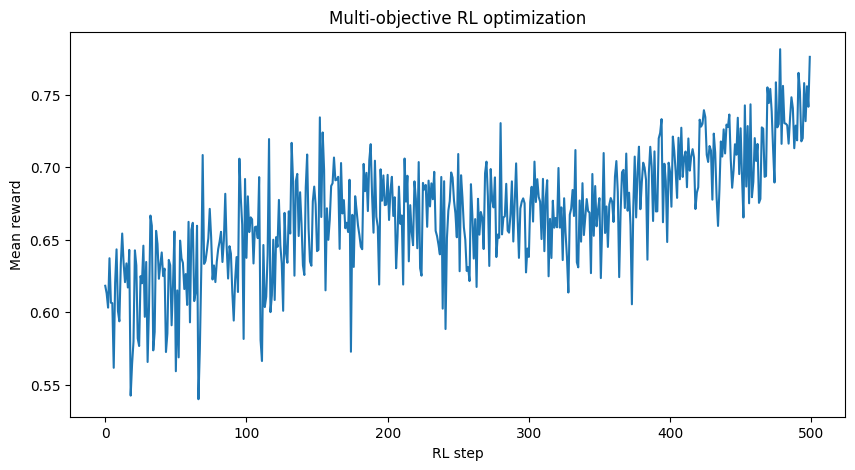

In [38]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["step"],
    history_df["reward"]
)

plt.xlabel("RL step")
plt.ylabel("Mean reward")
plt.title("Multi-objective RL optimization")

plt.show()

<h2> Generate a large optimized library </h2>

In [31]:
def generate_library(
    model,
    n=5000,
    temperature=0.7
):

    results = {}

    for _ in tqdm(
        range(n),
        desc="Generating molecules"
    ):

        sm = sample_smiles(
            model,
            temperature=temperature
        )

        mol = Chem.MolFromSmiles(sm)

        if mol is None:
            continue

        sm = Chem.MolToSmiles(
            mol,
            canonical=True
        )

        reward = multi_objective_reward(sm)

        results[sm] = reward

    return results

Generate

In [32]:
generated = generate_library(
    generator,
    n=5000,
    temperature=0.7
)

print(
    "Unique valid molecules:",
    len(generated)
)

Generating molecules:   0%|          | 0/5000 [00:00<?, ?it/s]

[14:23:39] SMILES Parse Error: unclosed ring for input: 'CCCCOc(=O)cccc1O'
[14:23:40] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 14 15
[14:23:40] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 14 15
[14:23:41] SMILES Parse Error: unclosed ring for input: 'O=Cc1ccccc1ONCCC1=O'
[14:23:41] Can't kekulize mol.  Unkekulized atoms: 1 2 3 7 8 9 10
[14:23:41] Can't kekulize mol.  Unkekulized atoms: 1 2 3 7 8 9 10
[14:23:41] Explicit valence for atom # 3 O, 3, is greater than permitted
[14:23:41] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 11 12
[14:23:41] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 11 12
[14:23:43] SMILES Parse Error: unclosed ring for input: 'CCc1ccccc1NCCC1=O'
[14:23:46] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10
[14:23:46] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10
[14:23:53] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11
[14:23:53] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11
[14:23:53] SMILES Parse Error:

Unique valid molecules: 2217


Evaluate the optimized molecules

In [33]:
records = []

for sm, reward in generated.items():

    props = molecular_properties(sm)

    if props is None:
        continue

    records.append({
        "SMILES": sm,
        "Reward": reward,
        **props
    })

results_df = pd.DataFrame(records)

results_df = results_df.sort_values(
    "Reward",
    ascending=False
)

results_df.head(20)

,SMILES,Reward,MW,LogP,TPSA,QED,HBD,HBA,Rings
1981,O=C(O)COc1ccc(O)cc1Br,0.936062,247.044,1.61810,66.76,0.851055,2,3,1
2190,CC(CCCC(=O)O)c1cnccc1O,0.931040,209.245,2.14560,70.42,0.779013,2,3,1
1900,CCC(CC(=O)O)c1ccccc1OCCO,0.926945,238.283,2.02600,66.76,0.762340,2,3,1
1669,CC(CCC(=O)O)c1ccccc1CN,0.924442,207.273,2.11360,63.32,0.776880,2,2,1
774,CC(CO)CCOc1ccccc1C(=O)O,0.924232,224.256,1.78210,66.76,0.772566,2,3,1
790,NCCCNC(=O)Oc1ccccc1Cl,0.920576,228.679,1.77720,64.35,0.772493,2,3,1
943,O=c1cccccc1Oc1ccccc1OCO,0.917745,244.246,2.16770,55.76,0.837284,1,4,2
1018,CC(CC(=O)O)C(O)c1ccccc1F,0.917016,212.220,1.96990,57.53,0.801748,2,2,1
1774,CC(CCC(=O)O)c1ccccc1OCO,0.915783,224.256,1.98350,66.76,0.724967,2,3,1
1262,O=C(O)Cc1ccc(Br)cc1O,0.915227,231.045,1.78180,57.53,0.815008,2,2,1


<h2> Inspect the Pareto front </h2>

This is important.

A weighted reward produces a single preferred solution, but multi-objective optimization is naturally a Pareto problem.

For example, QED and TPSA can conflict.

A molecule is Pareto-optimal if no other molecule improves one objective without worsening another.

In [34]:
def pareto_front(
    df,
    objectives,
    maximize=None
):

    if maximize is None:
        maximize = [True] * len(objectives)

    values = df[objectives].values.copy()

    for j, is_max in enumerate(maximize):

        if not is_max:
            values[:, j] *= -1

    keep = np.ones(len(df), dtype=bool)

    for i in range(len(df)):

        if not keep[i]:
            continue

        dominated = np.all(
            values >= values[i],
            axis=1
        ) & np.any(
            values > values[i],
            axis=1
        )

        dominated[i] = False

        if np.any(dominated):
            keep[i] = False

    return df[keep].copy()

In [35]:
pareto_df = pareto_front(
    results_df,
    objectives=[
        "QED",
        "TPSA",
        "Reward"
    ],
    maximize=[
        True,
        True,
        True
    ]
)

print(
    "Pareto molecules:",
    len(pareto_df)
)

pareto_df.head(20)

Pareto molecules: 27


,SMILES,Reward,MW,LogP,TPSA,QED,HBD,HBA,Rings
1981,O=C(O)COc1ccc(O)cc1Br,0.936062,247.044,1.61810,66.76,0.851055,2,3,1
2190,CC(CCCC(=O)O)c1cnccc1O,0.931040,209.245,2.14560,70.42,0.779013,2,3,1
1453,CCCNC(=O)Oc1ccccc1OCCO,0.912786,239.271,1.55610,67.79,0.790075,2,4,1
1316,CC(C(=O)O)c1ccccc1C(=O)O,0.904470,194.186,1.57290,74.60,0.765401,2,2,1
1889,NCc1ccc(CCOc2cccnc2)cc1,0.889028,228.295,2.16180,48.14,0.852730,1,3,2
1638,O=C(O)CCCC(O)c1ccccc1O,0.885315,210.229,1.68050,77.76,0.690537,3,3,1
187,NC(=O)c1ccccc1Oc1ccccc1,0.872741,213.236,2.57780,52.32,0.851418,1,2,2
567,CCOc1nccc(C(=O)O)c1OC,0.864742,197.190,1.18710,68.65,0.784584,1,4,1
1158,CP(=O)(O)Oc1ccccc1OCCO,0.857395,232.172,1.25170,75.99,0.747011,2,4,1
1747,Nc1nccc(Nc2cccnc2)n1,0.845521,187.206,1.19740,76.72,0.738193,2,5,2


<h2> Plot the multi-objective landscape </h2>

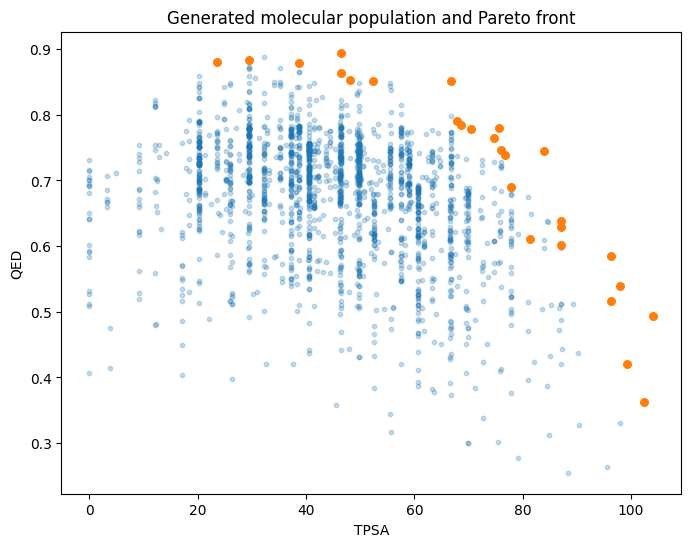

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    results_df["TPSA"],
    results_df["QED"],
    s=10,
    alpha=0.25
)

plt.scatter(
    pareto_df["TPSA"],
    pareto_df["QED"],
    s=30
)

plt.xlabel("TPSA")
plt.ylabel("QED")

plt.title(
    "Generated molecular population and Pareto front"
)

plt.show()

<h2> Visualize the best molecules </h2>

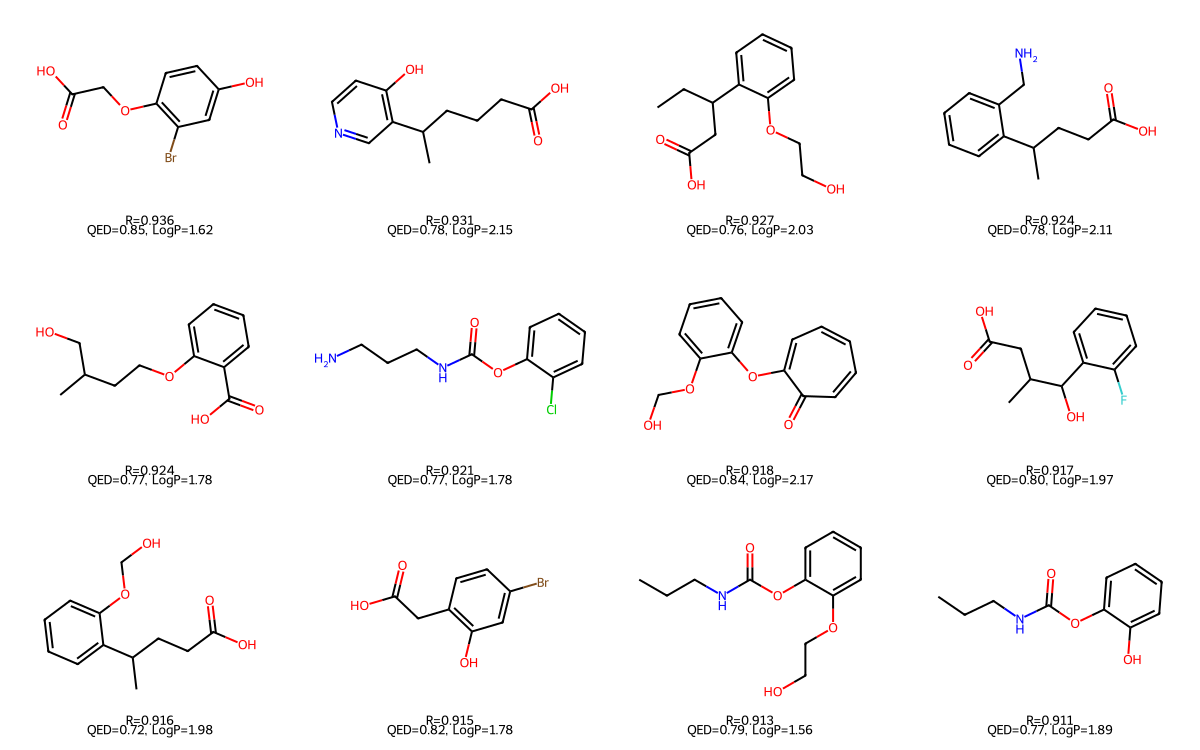

In [37]:
from rdkit.Chem import Draw

top = results_df.head(12)

mols = [
    Chem.MolFromSmiles(sm)
    for sm in top["SMILES"]
]

legends = [
    f"R={r:.3f}\n"
    f"QED={q:.2f}, "
    f"LogP={lp:.2f}"
    for r, q, lp in zip(
        top["Reward"],
        top["QED"],
        top["LogP"]
    )
]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 250),
    legends=legends
)

display(img)

<h2> Save Results </h2>

In [39]:
results_df.to_csv(
    "multiobjective_rl_molecules.csv",
    index=False
)

pareto_df.to_csv(
    "multiobjective_rl_pareto.csv",
    index=False
)

torch.save(
    generator.state_dict(),
    "multiobjective_rl_generator.pt"
)

print("Saved.")

Saved.
